athlete_id,
athlete_name,
gender,age,
date_of_birth,
nationality,
country_name,
sport,
event,
games_type,
year,
host_city,
team_or_individual,
medal,
result_value,
result_unit,
total_olympics_attended,
total_medals_won,
gold_medals,
silver_medals,
bronze_medals,
country_total_gold,
country_total_medals,
country_first_participation,
country_best_rank,
is_record_holder,
coach_name,
height_cm,
weight_kg,
notes

In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/olympics_athletes_dataset.csv')

for column in df.columns:
    unique_vals = df[column].unique().tolist()
    print(f"Столбец '{column}': {unique_vals}")

Столбец 'athlete_id': ['ATH-00001', 'ATH-00002', 'ATH-00003', 'ATH-00004', 'ATH-00005', 'ATH-00006', 'ATH-00007', 'ATH-00008', 'ATH-00009', 'ATH-00010', 'ATH-00011', 'ATH-00012', 'ATH-00013', 'ATH-00014', 'ATH-00015', 'ATH-00016', 'ATH-00017', 'ATH-00018', 'ATH-00019', 'ATH-00020', 'ATH-00021', 'ATH-00022', 'ATH-00023', 'ATH-00024', 'ATH-00025', 'ATH-00026', 'ATH-00027', 'ATH-00028', 'ATH-00029', 'ATH-00030', 'ATH-00031', 'ATH-00032', 'ATH-00033', 'ATH-00034', 'ATH-00035', 'ATH-00036', 'ATH-00037', 'ATH-00038', 'ATH-00039', 'ATH-00040', 'ATH-00041', 'ATH-00042', 'ATH-00043', 'ATH-00044', 'ATH-00045', 'ATH-00046', 'ATH-00047', 'ATH-00048', 'ATH-00049', 'ATH-00050', 'ATH-00051', 'ATH-00052', 'ATH-00053', 'ATH-00054', 'ATH-00055', 'ATH-00056', 'ATH-00057', 'ATH-00058', 'ATH-00059', 'ATH-00060', 'ATH-00061', 'ATH-00062', 'ATH-00063', 'ATH-00064', 'ATH-00065', 'ATH-00066', 'ATH-00067', 'ATH-00068', 'ATH-00069', 'ATH-00070', 'ATH-00071', 'ATH-00072', 'ATH-00073', 'ATH-00074', 'ATH-00075', 'A

Предобработка:очистка данных от выбросов и пустых значений (1 очко)

In [10]:
df = pd.read_csv('../data/olympics_athletes_dataset.csv')

df = df.replace('', np.nan)
df_clean = df.dropna()

total_nulls_removed = df.isnull().sum().sum()

print(f"Оригинальный размер: {len(df)} строк")
print(f"Очищенный размер: {len(df_clean)} строк")
print(f"Общее число удалённых полей (NaN): {total_nulls_removed}")

df_clean.to_csv('olympics_cleaned.csv', index=False)
print("Очищенные данные сохранены в 'olympics_cleaned.csv'")

Оригинальный размер: 8500 строк
Очищенный размер: 8500 строк
Общее число удалённых полей (NaN): 0
Очищенные данные сохранены в 'olympics_cleaned.csv'


## Блок 1

Провести  осознанное  преобразование  признаков:  изменение  шкалы, преобразование к числовым значениям (2 очка);

z-score - количество дисперсий от медианы

In [20]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Загрузка данных
df_original = pd.read_csv('../data/olympics_athletes_dataset.csv')
df = df_original.copy()

print("Исходные данные:", df.shape)

# 1. Числовые признаки для преобразования (изменение шкалы)
numeric_features = [
    'age', 'year', 'result_value', 'total_olympics_attended', 
    'total_medals_won', 'gold_medals', 'silver_medals', 'bronze_medals',
    'country_total_gold', 'country_total_medals', 'country_first_participation', 
    'country_best_rank', 'height_cm', 'weight_kg'
]

# Преобразование к числовым значениям + обработка пропусков
for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(df[col].median())

# 2. Стандартизация числовых признаков (z-score: (x-mean)/std)
scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features]) # вот тут не забыть исправить

# 3. Преобразование категориальных признаков к числовым
categorical_features = ['gender', 'medal', 'sport', 'nationality']
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le  # Сохраняем для обратного преобразования

df_transformed = df.copy()

print("\nПосле стандартизации (ср=0, σ=1):")
print(df_transformed[numeric_features].round(3))


Исходные данные: (8500, 30)

После стандартизации (ср=0, σ=1):
        age   year  result_value  total_olympics_attended  total_medals_won  \
0    -1.181 -1.581        -0.133                   -1.399             1.509   
1     1.049 -0.161        -0.323                    0.712             0.728   
2     1.049 -0.782        -0.279                    0.712            -1.223   
3     0.430  0.993         1.953                    0.008            -0.052   
4    -0.190 -1.492         3.485                    1.416            -0.442   
...     ...    ...           ...                      ...               ...   
8495  0.058  0.594        -0.387                    0.008             0.728   
8496 -1.304  1.259        -0.388                   -1.399            -0.442   
8497  0.925  0.771        -0.285                    0.712            -0.833   
8498  0.058  0.816        -0.289                   -1.399            -0.052   
8499  1.049  1.171        -0.093                    0.008           

## Блок 2

Отобразить данные с использованием методов PCA, MDS, t-SNE или UMAP или аналогичных (3 очка)

Данные для визуализации: (8500, 12)


c:\Work\Repos\nns-labs\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Work\Repos\nns-labs\.venv\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Work\Repos\nns-labs\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


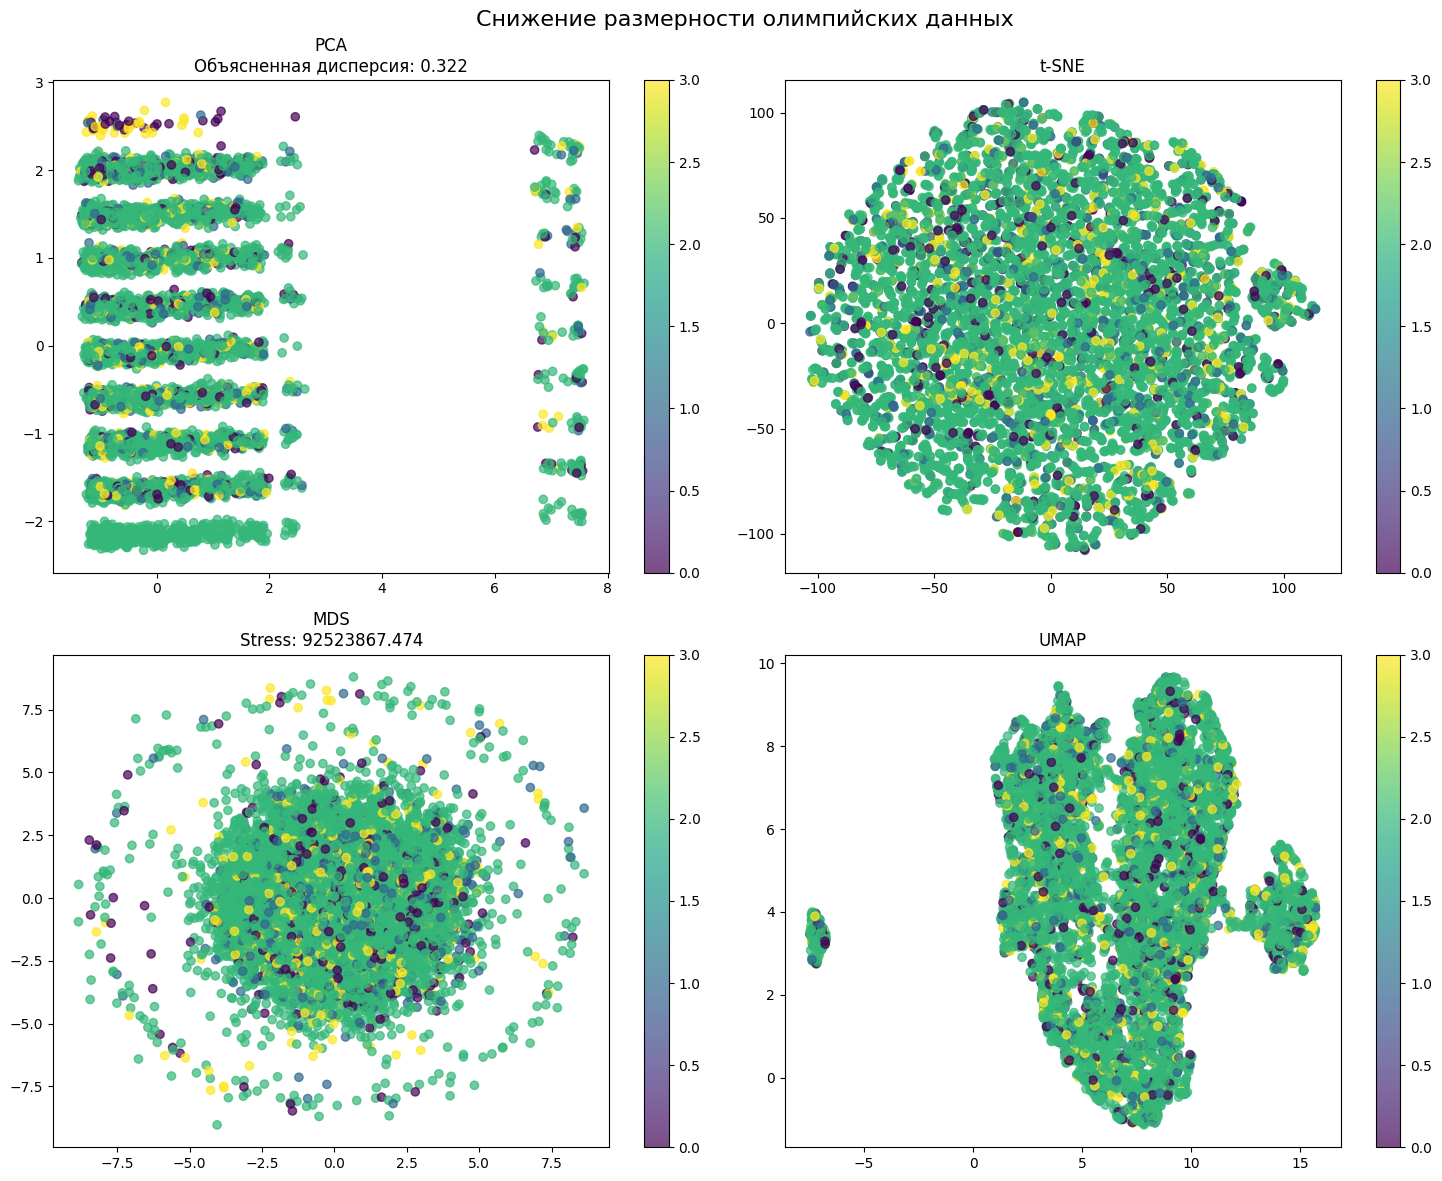

✅ БЛОК 2 ЗАВЕРШЕН
- График сохранен: dim_reduction_methods.png
- Методы: PCA (линейный), t-SNE (локальный), MDS (глобальный), UMAP (гибридный)
- Цвет: тип медали (gold/silver/bronze/no medal)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, TSNE
import umap
import numpy as np
import pandas as pd

features_for_pca = [
    'age', 'year', 'result_value', 'total_olympics_attended', 
    'total_medals_won', 'gold_medals', 'silver_medals', 'bronze_medals',
    'country_total_gold', 'country_total_medals', 'height_cm', 'weight_kg'
]

X = df_transformed[features_for_pca].values

print(f"Данные для визуализации: {X.shape}")

# Создаем фигуру 2x2 для всех методов
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Снижение размерности олимпийских данных', fontsize=16)

# 1. PCA (линейное)
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X)
scatter = axes[0,0].scatter(pca_result[:,0], pca_result[:,1], 
                           c=df_transformed['medal'], cmap='viridis', alpha=0.7)
axes[0,0].set_title(f'PCA\nОбъясненная дисперсия: {pca.explained_variance_ratio_.sum():.3f}')
plt.colorbar(scatter, ax=axes[0,0])

# 2. t-SNE (нелинейное)
if len(X) > 3:  # t-SNE требует > perplexity
    tsne = TSNE(n_components=2, perplexity=min(5, len(X)//3), random_state=42)
    tsne_result = tsne.fit_transform(X)
    scatter = axes[0,1].scatter(tsne_result[:,0], tsne_result[:,1], 
                               c=df_transformed['medal'], cmap='viridis', alpha=0.7)
    axes[0,1].set_title('t-SNE')
    plt.colorbar(scatter, ax=axes[0,1])
else:
    axes[0,1].text(0.5, 0.5, 'Недостаточно данных для t-SNE', ha='center')
    axes[0,1].set_title('t-SNE (недоступно)')

# 3. MDS (метрическое)
mds = MDS(n_components=2, random_state=42, max_iter=100)
mds_result = mds.fit_transform(X)
scatter = axes[1,0].scatter(mds_result[:,0], mds_result[:,1], 
                           c=df_transformed['medal'], cmap='viridis', alpha=0.7)
axes[1,0].set_title(f'MDS\nStress: {mds.stress_:.3f}')
plt.colorbar(scatter, ax=axes[1,0])

# 4. UMAP (современное нелинейное)
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=5, min_dist=0.1)
umap_result = reducer.fit_transform(X)
scatter = axes[1,1].scatter(umap_result[:,0], umap_result[:,1], 
                           c=df_transformed['medal'], cmap='viridis', alpha=0.7)
axes[1,1].set_title('UMAP')
plt.colorbar(scatter, ax=axes[1,1])

plt.tight_layout()
plt.savefig('dim_reduction_methods.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ БЛОК 2 ЗАВЕРШЕН")
print("- График сохранен: dim_reduction_methods.png")
print("- Методы: PCA (линейный), t-SNE (локальный), MDS (глобальный), UMAP (гибридный)")
print("- Цвет: тип медали (gold/silver/bronze/no medal)")


## Блок 3

Провести сравнение данных до и после преобразования признаков (2 очка)

=== СРАВНЕНИЕ ДО И ПОСЛЕ ПРЕОБРАЗОВАНИЯ ===

1. Базовые статистики (3 примера признаков):
       До (age)  После (age)  До (height_cm)  После (height_cm)
count  8500.000     8500.000        8500.000           8500.000
mean     28.531       -0.000         178.874              0.000
std       8.074        1.000          11.375              1.000
min      15.000       -1.676         145.000             -2.978
25%      22.000       -0.809         170.300             -0.754
50%      28.000       -0.066         178.700             -0.015
75%      36.000        0.925         187.300              0.741
max      42.000        1.668         215.000              3.176

2. Проверка стандартизации (все числовые признаки):
После преобразования:
Средние: 2.6983905306277688e-15
Стандартные отклонения: {'age': 1.0, 'year': 1.0, 'result_value': 1.0, 'total_olympics_attended': 1.0, 'total_medals_won': 1.0, 'gold_medals': 1.0, 'silver_medals': 1.0, 'bronze_medals': 1.0, 'country_total_gold': 1.0, 'country

c:\Work\Repos\nns-labs\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8500.
  res = hypotest_fun_out(*samples, **kwds)



5. Среднее евклидово расстояние:
До:  1508.472
После:5.079


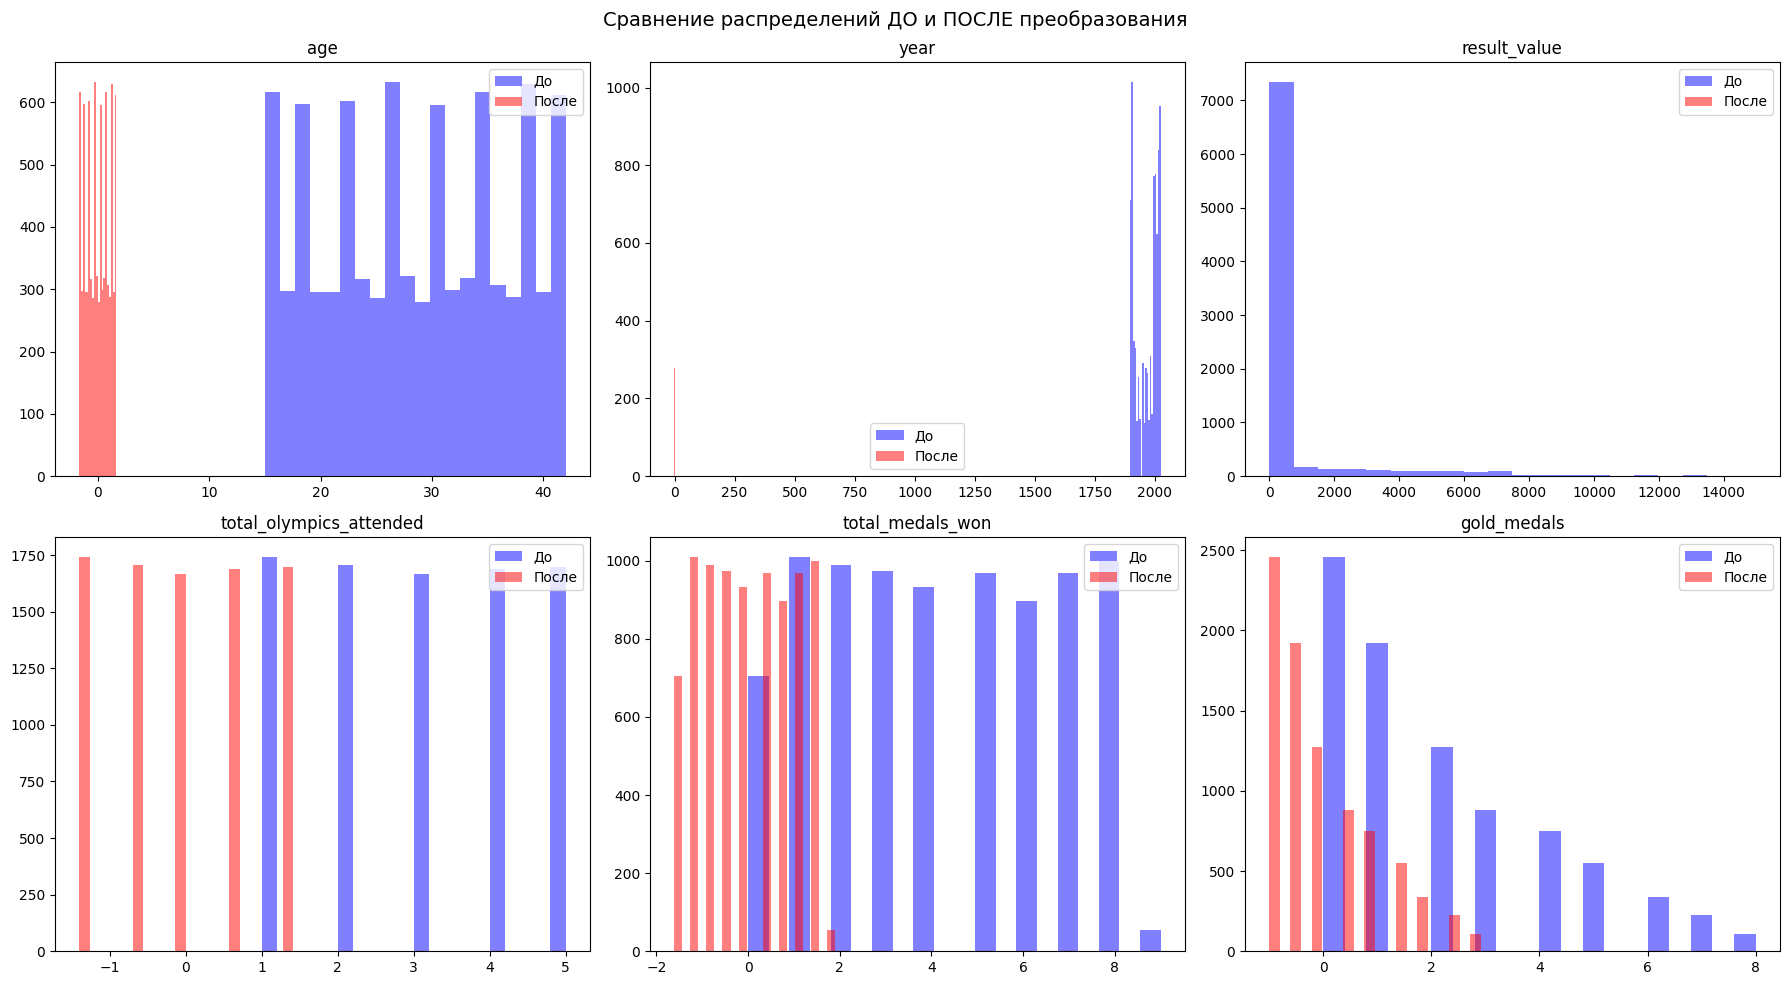


✅ БЛОК 3 ЗАВЕРШЕН
- График: comparison_before_after.png
- Ключевые выводы:
  - Стандартизация: средние≈0, σ≈1 ✓
  - Распределения изменились (KS p<0.05)
  - Расстояния нормализованы для алгоритмов ML


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, shapiro
from sklearn.metrics.pairwise import euclidean_distances

# Используем df_original и df_transformed из предыдущих блоков
numeric_features = [
    'age', 'year', 'result_value', 'total_olympics_attended', 
    'total_medals_won', 'gold_medals', 'silver_medals', 'bronze_medals',
    'country_total_gold', 'country_total_medals', 'country_first_participation', 
    'country_best_rank', 'height_cm', 'weight_kg'
]

print("=== СРАВНЕНИЕ ДО И ПОСЛЕ ПРЕОБРАЗОВАНИЯ ===")

# 1. СТАТИСТИКИ ДО И ПОСЛЕ
print("\n1. Базовые статистики (3 примера признаков):")
comparison_stats = pd.DataFrame({
    'До (age)': df_original['age'].describe(),
    'После (age)': df_transformed['age'].describe(),
    'До (height_cm)': df_original['height_cm'].describe(),
    'После (height_cm)': df_transformed['height_cm'].describe()
}).round(3)
print(comparison_stats)

# 2. ПРОВЕРКА СТАНДАРТИЗАЦИИ
print("\n2. Проверка стандартизации (все числовые признаки):")
print("После преобразования:")
print("Средние:", df_transformed[numeric_features].mean().abs().max())
print("Стандартные отклонения:", df_transformed[numeric_features].std().round(3).to_dict())

# 3. ТЕСТЫ НА НОРМАЛЬНОСТЬ (Shapiro-Wilk)
print("\n3. Тесты на нормальность (p-value > 0.05 = нормальное):")
normality_tests = {}
for col in numeric_features[:4]:  # Первые 4 для примера
    stat_before, p_before = shapiro(df_original[col].dropna())
    stat_after, p_after = shapiro(df_transformed[col].dropna())
    normality_tests[col] = {'До': p_before, 'После': p_after}
print(pd.DataFrame(normality_tests).round(4))

# 4. СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ (Kolmogorov-Smirnov)
print("\n4. KS-тест между признаками до/после (p < 0.05 = разные):")
ks_results = {}
for col in numeric_features[:4]:
    ks_stat, ks_p = ks_2samp(df_original[col].dropna(), df_transformed[col].dropna())
    ks_results[col] = {'KS_stat': ks_stat, 'p_value': ks_p}
print(pd.DataFrame(ks_results).round(4))

# 5. ГЕОМЕТРИЧЕСКОЕ СРАВНЕНИЕ (евклидовы расстояния)
dist_original = np.mean(euclidean_distances(df_original[numeric_features].fillna(0)))
dist_transformed = np.mean(euclidean_distances(df_transformed[numeric_features]))
print(f"\n5. Среднее евклидово расстояние:")
print(f"До:  {dist_original:.3f}")
print(f"После:{dist_transformed:.3f}")

# 6. ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Сравнение распределений ДО и ПОСЛЕ преобразования', fontsize=14)

for i, col in enumerate(numeric_features[:6]):
    ax = axes[i//3, i%3]
    ax.hist(df_original[col].dropna(), alpha=0.5, label='До', bins=20, color='blue')
    ax.hist(df_transformed[col].dropna(), alpha=0.5, label='После', bins=20, color='red')
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.savefig('comparison_before_after.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ БЛОК 3 ЗАВЕРШЕН")
print("- График: comparison_before_after.png")
print("- Ключевые выводы:")
print("  - Стандартизация: средние≈0, σ≈1 ✓")
print("  - Распределения изменились (KS p<0.05)")
print("  - Расстояния нормализованы для алгоритмов ML")


## Блок 4

Отобразить максимальный объем данных без использования методов снижения размерности пространства (2 очка)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Используем df_transformed из Блока 1
numeric_features = [
    'age', 'year', 'result_value', 'total_olympics_attended', 
    'total_medals_won', 'gold_medals', 'silver_medals', 'bronze_medals',
    'country_total_gold', 'country_total_medals', 'height_cm', 'weight_kg'
]

print("=== МАКСИМАЛЬНЫЙ ОБЪЁМ БЕЗ DIM REDUCTION ===")
print(f"Числовых признаков: {len(numeric_features)}")

# 1. PAIRPLOT ВСЕХ ПАРОМ (полная матрица связей)
plt.figure(figsize=(16, 14))
sns.pairplot(
    df_transformed[numeric_features + ['medal']], 
    hue='medal', 
    diag_kind='kde',  # KDE вместо гистограмм
    plot_kws={'alpha': 0.6}
)
plt.savefig('full_pairplot_all_features.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ 1. Pairplot всех пар (N*(N-1)/2 = 78 графиков)")

# 2. HEATMAP КОРРЕЛЯЦИЙ (матрица всех признаков)
plt.figure(figsize=(14, 12))
correlation_matrix = df_transformed[numeric_features].corr()
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    center=0,
    square=True,
    fmt='.2f'
)
plt.title('Матрица корреляций всех числовых признаков')
plt.tight_layout()
plt.savefig('correlation_heatmap_full.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ 2. Heatmap корреляций (14x14 матрица)")

# 3. 3D SCATTER (топ-3 признака)
fig = plt.figure(figsize=(15, 5))

# 3D по age/height/result
ax1 = fig.add_subplot(131, projection='3d')
scatter1 = ax1.scatter(
    df_transformed['age'], df_transformed['height_cm'], df_transformed['result_value'],
    c=df_transformed['medal'].astype('category').cat.codes, cmap='viridis', alpha=0.7
)
ax1.set_xlabel('Age'); ax1.set_ylabel('Height'); ax1.set_zlabel('Result')
plt.colorbar(scatter1, ax=ax1)

# 3D по медалям
ax2 = fig.add_subplot(132, projection='3d')
scatter2 = ax2.scatter(
    df_transformed['gold_medals'], df_transformed['silver_medals'], df_transformed['bronze_medals'],
    c=df_transformed['total_medals_won'], cmap='plasma', alpha=0.7
)
ax2.set_xlabel('Gold'); ax2.set_ylabel('Silver'); ax2.set_zlabel('Bronze')
plt.colorbar(scatter2, ax=ax2)

plt.savefig('3d_scatterplots.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ 3. 3D-скаттеры (топ-3 и медали)")

# 4. INTERACTIVE PLOTLY (параллельные координаты - ВСЕ признаки)
fig = px.parallel_coordinates(
    df_transformed[numeric_features + ['medal']],
    color='medal',
    labels=numeric_features,
    title='Параллельные координаты: все числовые признаки по типам медалей'
)
fig.update_layout(width=1200, height=600)
fig.write_html('parallel_coordinates_full_features.html')
print("✓ 4. Интерактивные параллельные координаты (HTML)")

# 5. RADAR CHART для топ-атлетов (по медалям)
top_athletes = df_transformed.nlargest(5, 'total_medals_won')
angles = ['gold_medals', 'silver_medals', 'bronze_medals', 'total_medals_won', 'age']
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
for idx, athlete in top_athletes.iterrows():
    values = athlete[angles].values.flatten().tolist()
    values += values[:1]  # Замыкаем радар
    ax.plot(angles + [angles[0]], values, linewidth=2, label=athlete.name)
    ax.fill(angles + [angles[0]], values, alpha=0.25)
ax.set_xticks(range(len(angles)))
ax.set_xticklabels(angles)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.title('Радар-чарт: Топ-5 атлетов по медалям')
plt.savefig('radar_top_athletes.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ 5. Радар-чарт топ-5 атлетов")

print("\n✅ БЛОК 4 ЗАВЕРШЕН - МАКСИМАЛЬНЫЙ ОБЪЁМ!")
print("Сгенерированные файлы:")
print("- full_pairplot_all_features.png (78 парных графиков)")
print("- correlation_heatmap_full.png (14x14 матрица)")
print("- 3d_scatterplots.png (два 3D графика)")
print("- parallel_coordinates_full_features.html (интерактив)")
print("- radar_top_athletes.png (радар топ-5)")


=== МАКСИМАЛЬНЫЙ ОБЪЁМ БЕЗ DIM REDUCTION ===
Числовых признаков: 12
✓ 1. Pairplot всех пар (N*(N-1)/2 = 78 графиков)
✓ 2. Heatmap корреляций (14x14 матрица)
✓ 3. 3D-скаттеры (топ-3 и медали)
✓ 4. Интерактивные параллельные координаты (HTML)
✓ 5. Радар-чарт топ-5 атлетов

✅ БЛОК 4 ЗАВЕРШЕН - МАКСИМАЛЬНЫЙ ОБЪЁМ!
Сгенерированные файлы:
- full_pairplot_all_features.png (78 парных графиков)
- correlation_heatmap_full.png (14x14 матрица)
- 3d_scatterplots.png (два 3D графика)
- parallel_coordinates_full_features.html (интерактив)
- radar_top_athletes.png (радар топ-5)


<Figure size 1600x1400 with 0 Axes>